In [2]:
import sys
import os

print("Python:", sys.executable)
print("Current folder:", os.getcwd())
print("Files:", os.listdir())

Python: c:\Users\Darsh maru\AppData\Local\Programs\Python\Python313\python.exe
Current folder: d:\AI_Financial_Fraud_Detection
Files: ['01_EDA_Preprocessing.ipynb', 'all_model_comparison.csv', 'baseline_model_comparison.csv', 'creditcard.csv', 'results_class_distribution.png', 'train_test_data.pkl']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Basic dataset information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 

In [5]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [6]:
# Check missing values
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

Total missing values: 0

Columns with missing values:
Series([], dtype: int64)


In [7]:
# Class distribution
class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
class_percentages = df["Class"].value_counts(normalize=True) * 100

print(class_percentages)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


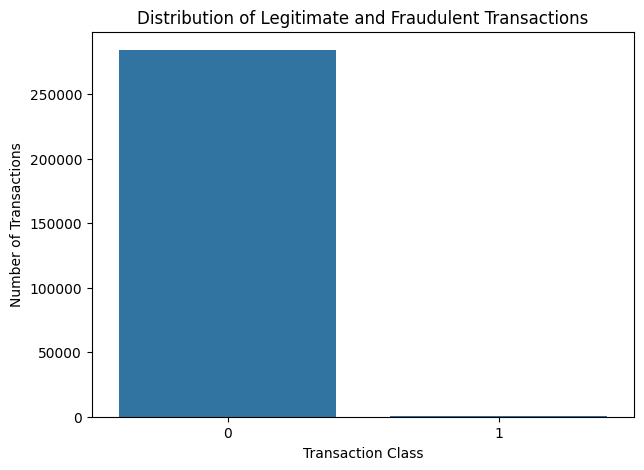

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

In [10]:
plt.savefig("results_class_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [11]:
print(df["Amount"].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


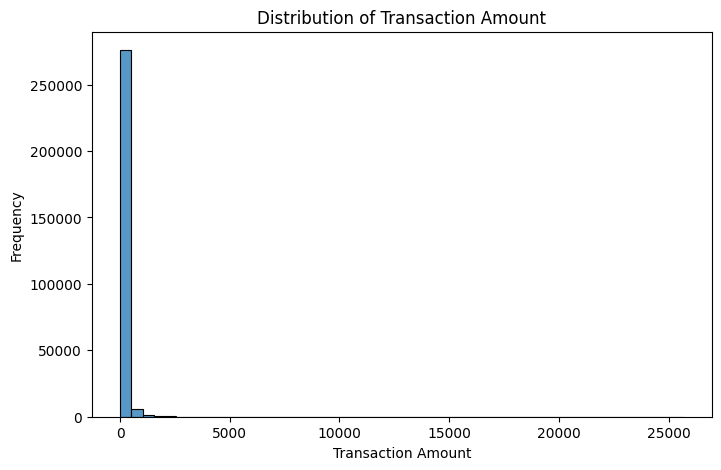

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Amount"], bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [13]:
df["Log_Amount"] = np.log1p(df["Amount"])

In [14]:
df[["Amount", "Log_Amount"]].head()

,Amount,Log_Amount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


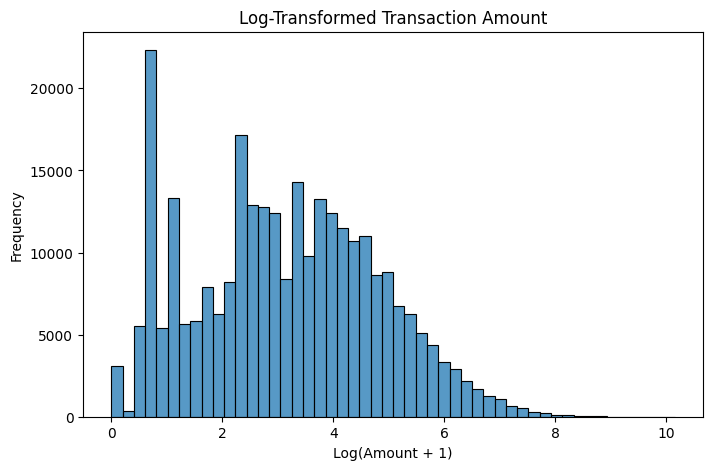

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Log_Amount"], bins=50)

plt.title("Log-Transformed Transaction Amount")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")

plt.show()

In [16]:
df["Hour"] = (df["Time"] / 3600) % 24
df[["Time", "Hour", "Class"]].head()

,Time,Hour,Class
0,0.0,0.000000,0
1,0.0,0.000000,0
2,1.0,0.000278,0
3,1.0,0.000278,0
4,2.0,0.000556,0


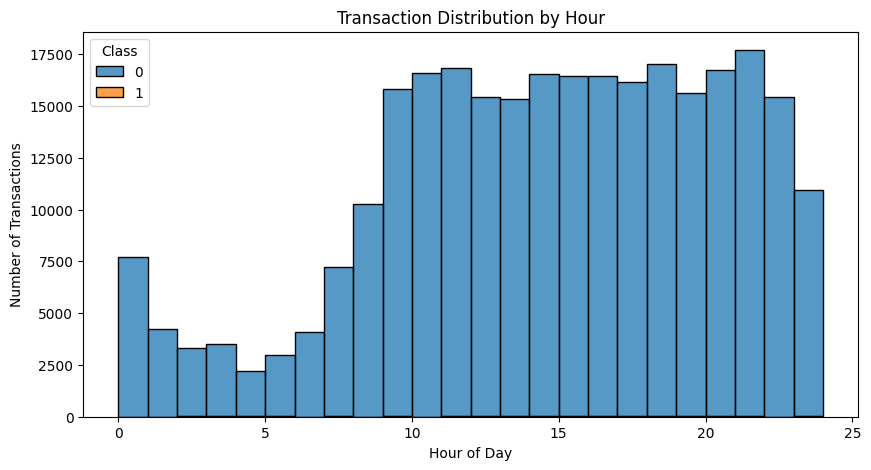

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Hour",
    hue="Class",
    bins=24,
    multiple="stack"
)

plt.title("Transaction Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

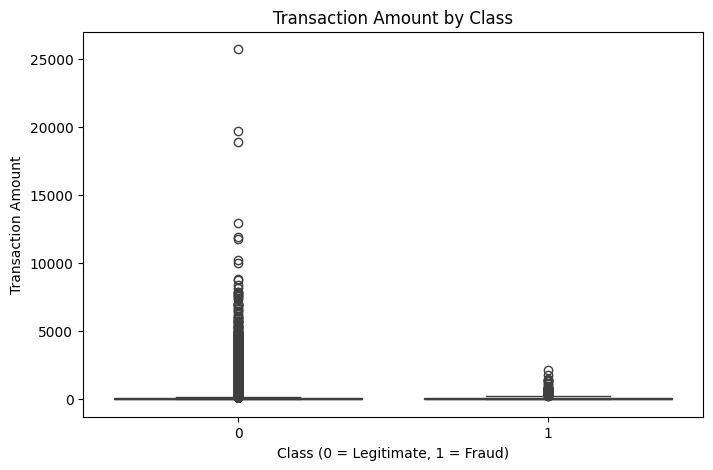

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

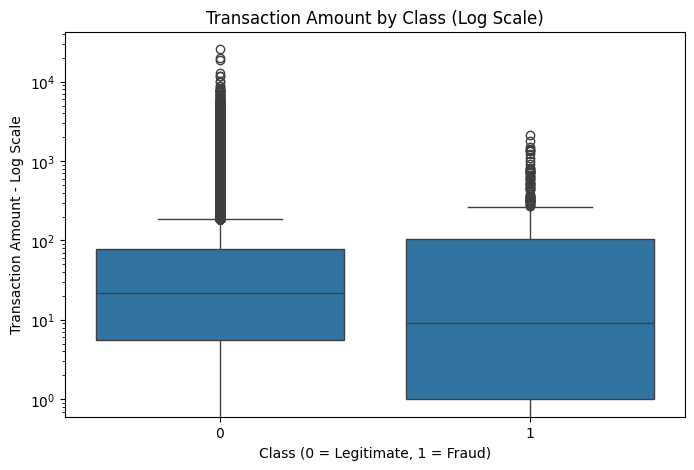

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.yscale("log")

plt.title("Transaction Amount by Class (Log Scale)")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount - Log Scale")

plt.show()

In [20]:
# Correlation of each feature with the target
correlation_with_class = df.corr(numeric_only=True)["Class"].sort_values(
    ascending=False
)

print(correlation_with_class)

Class         1.000000
V11           0.154876
V4            0.133447
V2            0.091289
V21           0.040413
V19           0.034783
V20           0.020090
V8            0.019875
V27           0.017580
V28           0.009536
Amount        0.005632
V26           0.004455
V25           0.003308
V22           0.000805
V23          -0.002685
V15          -0.004223
V13          -0.004570
V24          -0.007221
Log_Amount   -0.008326
Time         -0.012323
Hour         -0.017082
V6           -0.043643
V5           -0.094974
V9           -0.097733
V1           -0.101347
V18          -0.111485
V7           -0.187257
V3           -0.192961
V16          -0.196539
V10          -0.216883
V12          -0.260593
V14          -0.302544
V17          -0.326481
Name: Class, dtype: float64


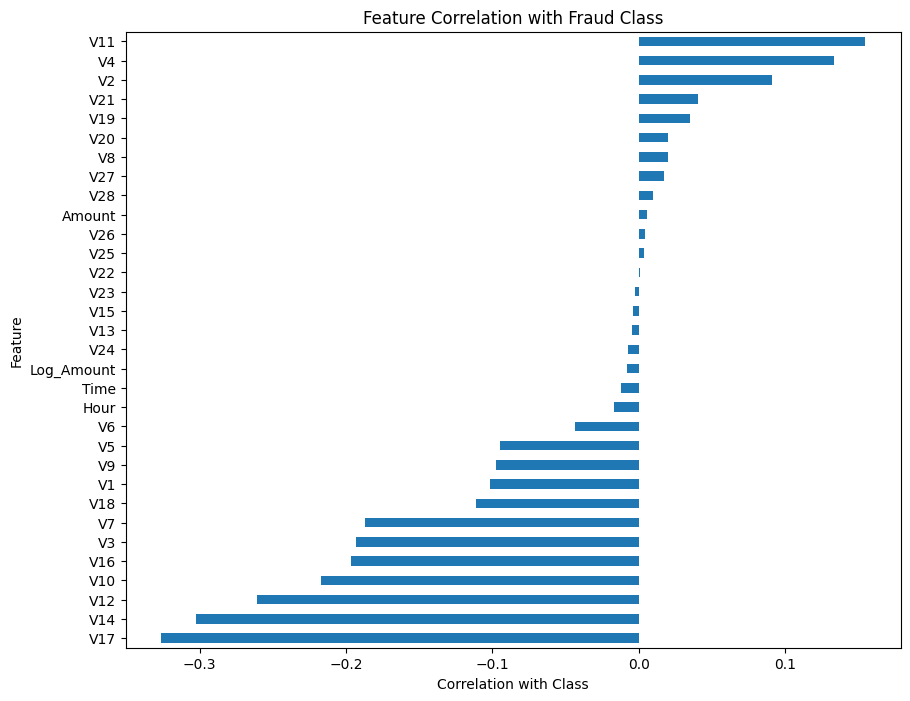

In [21]:
plt.figure(figsize=(10, 8))

correlation_with_class.drop("Class").sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.show()

In [22]:
# Select V1-V28
v_features = [f"V{i}" for i in range(1, 29)]

# Calculate mean values for each class
class_means = df.groupby("Class")[v_features].mean().T

print(class_means)

Class         0         1
V1     0.008258 -4.771948
V2    -0.006271  3.623778
V3     0.012171 -7.033281
V4    -0.007860  4.542029
V5     0.005453 -3.151225
V6     0.002419 -1.397737
V7     0.009637 -5.568731
V8    -0.000987  0.570636
V9     0.004467 -2.581123
V10    0.009824 -5.676883
V11   -0.006576  3.800173
V12    0.010832 -6.259393
V13    0.000189 -0.109334
V14    0.012064 -6.971723
V15    0.000161 -0.092929
V16    0.007164 -4.139946
V17    0.011535 -6.665836
V18    0.003887 -2.246308
V19   -0.001178  0.680659
V20   -0.000644  0.372319
V21   -0.001235  0.713588
V22   -0.000024  0.014049
V23    0.000070 -0.040308
V24    0.000182 -0.105130
V25   -0.000072  0.041449
V26   -0.000089  0.051648
V27   -0.000295  0.170575
V28   -0.000131  0.075667


In [23]:
class_difference = (
    class_means[1] - class_means[0]
).abs().sort_values(ascending=False)

print(class_difference)

V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749
V2     3.630049
V5     3.156678
V9     2.585589
V18    2.250195
V6     1.400155
V21    0.714823
V19    0.681837
V8     0.571623
V20    0.372964
V27    0.170870
V13    0.109523
V24    0.105312
V15    0.093090
V28    0.075798
V26    0.051738
V25    0.041521
V23    0.040378
V22    0.014073
dtype: float64


V17           0.008258
V14           0.008136
V12           0.007601
V10           0.007530
V11           0.006831
V16           0.006144
V4            0.004976
V3            0.004952
V18           0.004317
V9            0.004277
V7            0.003951
V2            0.003228
V21           0.002452
V27           0.002444
V5            0.002389
V6            0.002388
V1            0.002127
Time          0.001908
V8            0.001898
V28           0.001871
Log_Amount    0.001695
Hour          0.001593
Amount        0.001532
V19           0.001472
V20           0.001207
V23           0.000762
V24           0.000642
V26           0.000500
V25           0.000498
V13           0.000408
V22           0.000353
V15           0.000315
dtype: float64


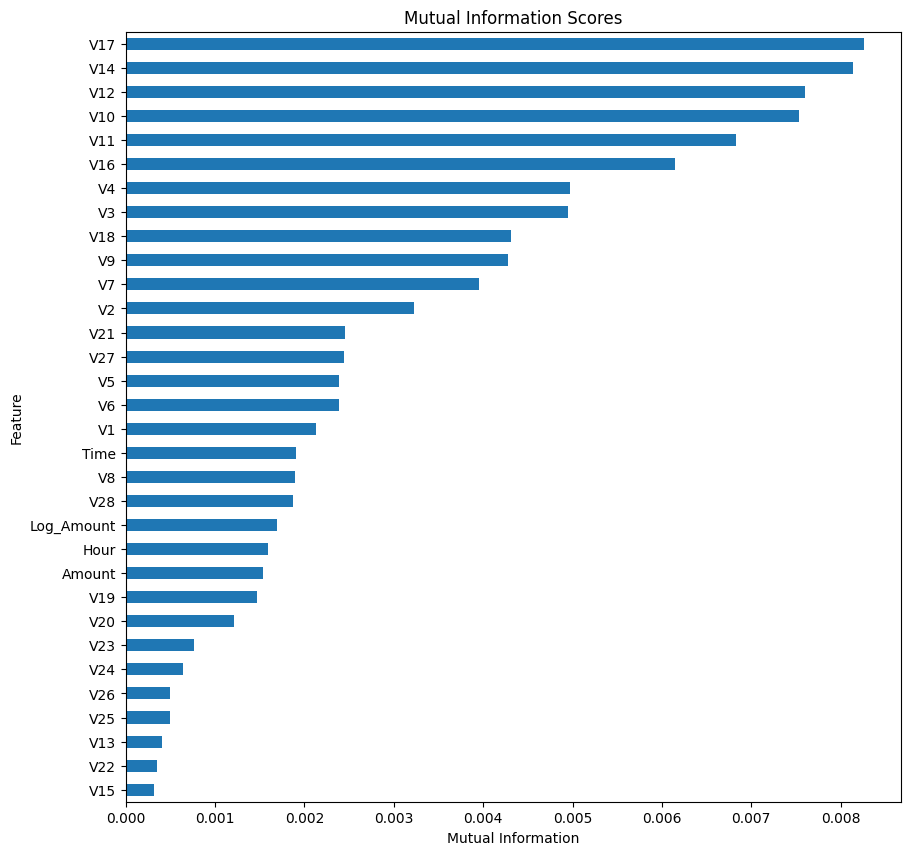

In [24]:
from sklearn.feature_selection import mutual_info_classif
feature_columns = [
    col for col in df.columns
    if col != "Class"
]

X_mi = df[feature_columns]
y_mi = df["Class"]
mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=feature_columns
).sort_values(ascending=False)

print(mi_scores)
plt.figure(figsize=(10, 10))

mi_scores.sort_values().plot(kind="barh")

plt.title("Mutual Information Scores")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.show()

In [25]:
feature_ranking = pd.DataFrame({
    "Feature": mi_scores.index,
    "Mutual_Information": mi_scores.values
})

feature_ranking.head(15)

,Feature,Mutual_Information
0,V17,0.008258
1,V14,0.008136
2,V12,0.007601
3,V10,0.007530
4,V11,0.006831
5,V16,0.006144
6,V4,0.004976
7,V3,0.004952
8,V18,0.004317
9,V9,0.004277


In [26]:
features = [
    col for col in df.columns
    if col != "Class"
]

X = df[features]
y = df["Class"]

print("Number of features:", X.shape[1])
print("Feature names:")
print(X.columns.tolist())

Number of features: 32
Feature names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Log_Amount', 'Hour']


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (227845, 32)
Testing set: (56962, 32)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [28]:
import joblib

joblib.dump(
    (X_train, X_test, y_train, y_test),
    "train_test_data.pkl"
)

print("Train/test data saved successfully.")

Train/test data saved successfully.


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression completed.")

Logistic Regression completed.


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(name, y_true, y_pred, y_prob):

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

    print(f"\n{name}")
    print("-" * 50)

    for metric, value in results.items():
        if metric != "Model":
            print(f"{metric}: {value:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        zero_division=0
    ))

    return results

In [31]:
lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)


Logistic Regression
--------------------------------------------------
Accuracy: 0.9735
Precision: 0.0560
Recall: 0.9082
F1-Score: 0.1055
ROC-AUC: 0.9732
PR-AUC: 0.7242

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.91      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962



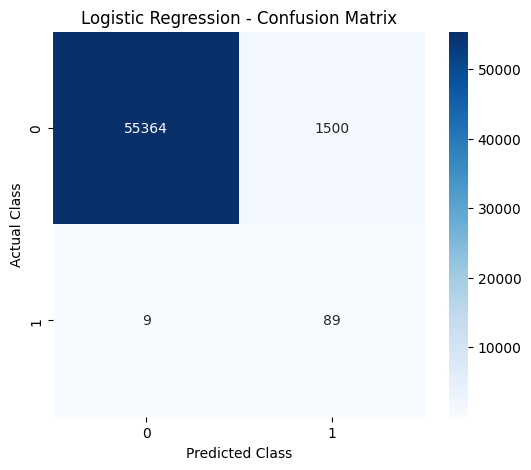

In [32]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)


Random Forest
--------------------------------------------------
Accuracy: 0.9995
Precision: 0.9286
Recall: 0.7959
F1-Score: 0.8571
ROC-AUC: 0.9558
PR-AUC: 0.8669

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.80      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [34]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)


XGBoost
--------------------------------------------------
Accuracy: 0.9995
Precision: 0.9176
Recall: 0.7959
F1-Score: 0.8525
ROC-AUC: 0.9779
PR-AUC: 0.8574

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.80      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [35]:
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

results_df
results_df.set_index("Model")
results_df.to_csv(
    "baseline_model_comparison.csv",
    index=False
)

print("Baseline results saved.")

Baseline results saved.


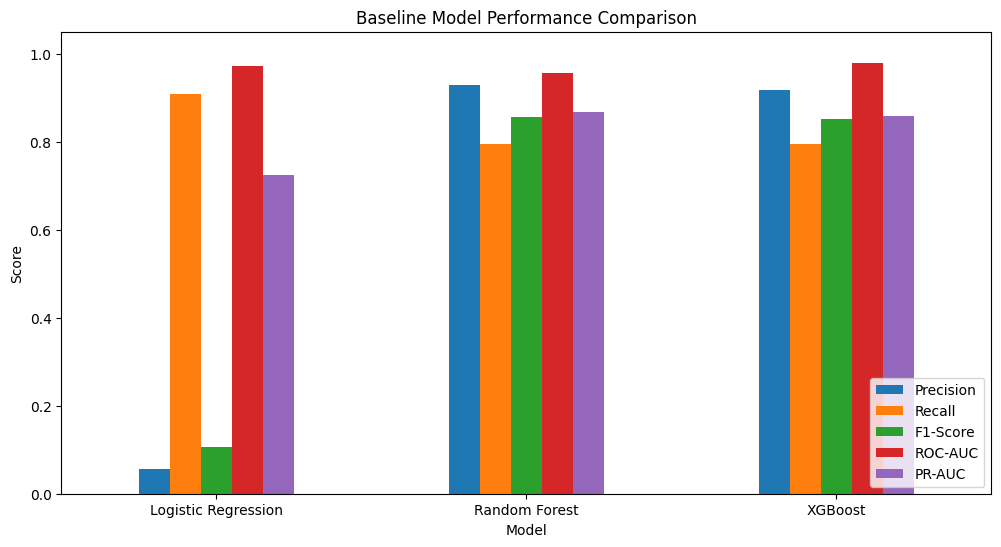

In [36]:
metrics = [
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

comparison = results_df.set_index("Model")[metrics]

comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

V14    0.182485
V10    0.114241
V12    0.110069
V4     0.103889
V17    0.075887
V11    0.068388
V3     0.055113
V16    0.038244
V7     0.035377
V9     0.019262
V2     0.017464
V18    0.015406
V19    0.013057
V20    0.012107
V21    0.011990
dtype: float64


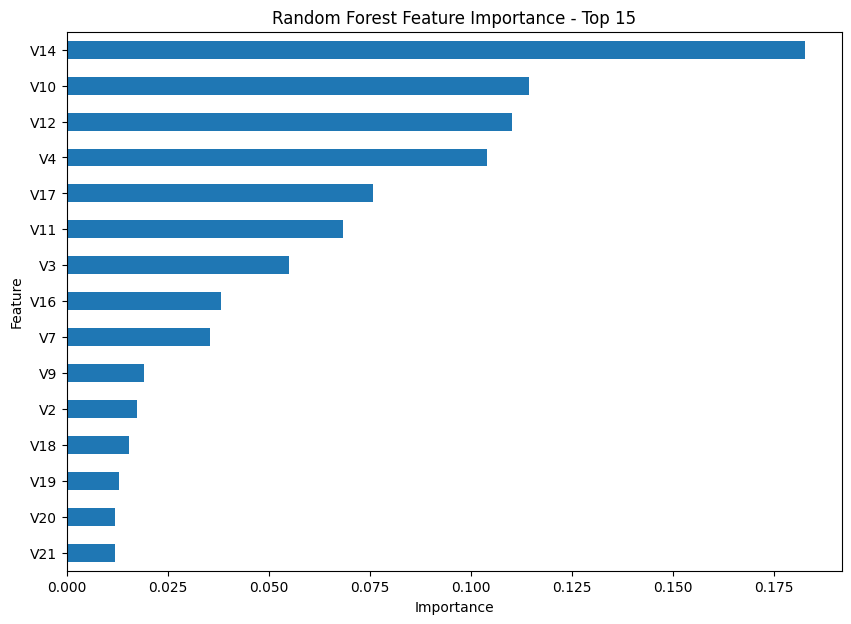

In [37]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(15))
plt.figure(figsize=(10, 7))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance - Top 15")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [38]:
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

results_df
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

V14    0.182485
V10    0.114241
V12    0.110069
V4     0.103889
V17    0.075887
V11    0.068388
V3     0.055113
V16    0.038244
V7     0.035377
V9     0.019262
V2     0.017464
V18    0.015406
V19    0.013057
V20    0.012107
V21    0.011990
dtype: float64


In [39]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original training set:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nOriginal training shape:", X_train.shape)
print("SMOTE training shape:", X_train_smote.shape)

Original training set:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Original training shape: (227845, 32)
SMOTE training shape: (454902, 32)


In [40]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

rf_smote_pred = rf_smote.predict(X_test)
rf_smote_prob = rf_smote.predict_proba(X_test)[:, 1]

rf_smote_results = evaluate_model(
    "Random Forest + SMOTE",
    y_test,
    rf_smote_pred,
    rf_smote_prob
)


Random Forest + SMOTE
--------------------------------------------------
Accuracy: 0.9995
Precision: 0.8526
Recall: 0.8265
F1-Score: 0.8394
ROC-AUC: 0.9669
PR-AUC: 0.8691

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [41]:
xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_smote.fit(X_train_smote, y_train_smote)

xgb_smote_pred = xgb_smote.predict(X_test)
xgb_smote_prob = xgb_smote.predict_proba(X_test)[:, 1]

xgb_smote_results = evaluate_model(
    "XGBoost + SMOTE",
    y_test,
    xgb_smote_pred,
    xgb_smote_prob
)


XGBoost + SMOTE
--------------------------------------------------
Accuracy: 0.9993
Precision: 0.7544
Recall: 0.8776
F1-Score: 0.8113
ROC-AUC: 0.9834
PR-AUC: 0.8811

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.88      0.81        98

    accuracy                           1.00     56962
   macro avg       0.88      0.94      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [42]:
all_results = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results,
    rf_smote_results,
    xgb_smote_results
])

all_results
all_results.to_csv(
    "all_model_comparison.csv",
    index=False
)

print("All baseline and SMOTE results saved.")

All baseline and SMOTE results saved.


In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

thresholds = np.arange(0.05, 0.96, 0.05)

for threshold in thresholds:

    threshold_pred = (
        xgb_smote_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.05,0.392857,0.897959,0.546584
1,0.10,0.517647,0.897959,0.656716
2,0.15,0.572368,0.887755,0.696000
3,0.20,0.618705,0.877551,0.725738
4,0.25,0.671875,0.877551,0.761062
5,0.30,0.688000,0.877551,0.771300
6,0.35,0.699187,0.877551,0.778281
7,0.40,0.710744,0.877551,0.785388
8,0.45,0.722689,0.877551,0.792627
9,0.50,0.754386,0.877551,0.811321


In [44]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

print("Best threshold based on F1-score:")
print(best_threshold_row)

Best threshold based on F1-score:
Threshold    0.900000
Precision    0.893617
Recall       0.857143
F1-Score     0.875000
Name: 17, dtype: float64


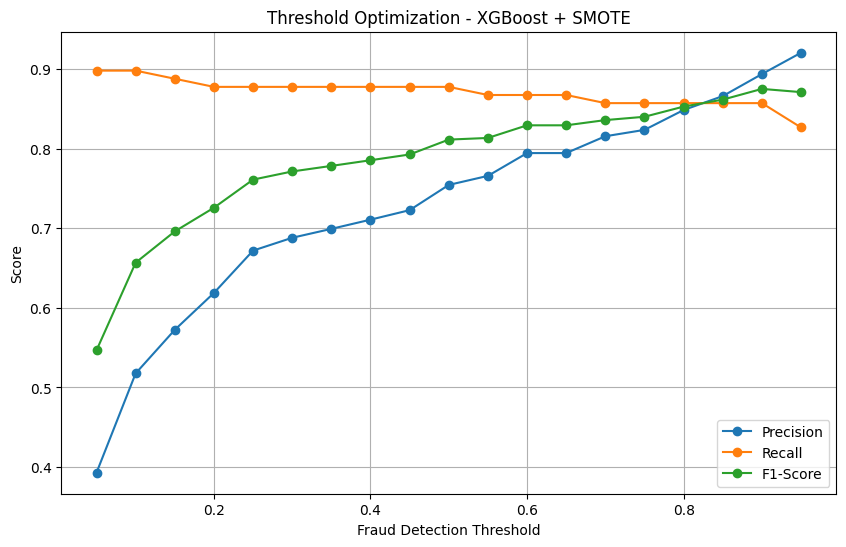

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Fraud Detection Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization - XGBoost + SMOTE")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
## Threshold Optimization
# The default classification threshold of 0.50 was further investigated because
# financial fraud detection involves a trade-off between detecting fraudulent
# transactions and reducing false positives. Multiple thresholds from 0.05 to
# 0.95 were evaluated using precision, recall, and F1-score.

# For the XGBoost + SMOTE model, the threshold of 0.90 achieved the highest
# F1-score of 0.8750, with a precision of 89.36% and recall of 85.71%.
# Compared with the default threshold of 0.50, the optimized threshold improved
# precision from 75.44% to 89.36% and F1-score from 81.13% to 87.50%, while
# recall decreased slightly from 87.76% to 85.71%.

# Therefore, 0.90 was selected as the F1-optimized threshold for the current
# experimental configuration.


SyntaxError: invalid syntax (2813560013.py, line 3)

In [47]:
optimal_threshold = 0.90

xgb_optimized_pred = (
    xgb_smote_prob >= optimal_threshold
).astype(int)

print("Optimized Threshold:", optimal_threshold)
optimized_results = evaluate_model(
    "XGBoost + SMOTE + Optimized Threshold",
    y_test,
    xgb_optimized_pred,
    xgb_smote_prob
)

Optimized Threshold: 0.9

XGBoost + SMOTE + Optimized Threshold
--------------------------------------------------
Accuracy: 0.9996
Precision: 0.8936
Recall: 0.8571
F1-Score: 0.8750
ROC-AUC: 0.9834
PR-AUC: 0.8811

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.86      0.88        98

    accuracy                           1.00     56962
   macro avg       0.95      0.93      0.94     56962
weighted avg       1.00      1.00      1.00     56962



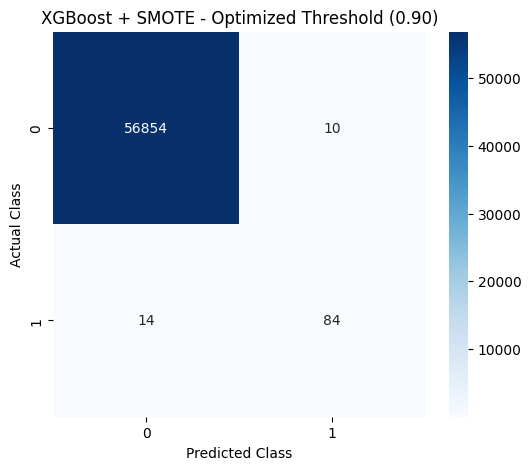

In [48]:
cm_optimized = confusion_matrix(
    y_test,
    xgb_optimized_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_optimized,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "XGBoost + SMOTE - Optimized Threshold (0.90)"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [49]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [50]:
param_dist = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.19),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 0.5)
}

In [51]:
xgb_for_search = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [52]:
random_search = RandomizedSearchCV(
    estimator=xgb_for_search,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [53]:
random_search.fit(
    X_train_smote,
    y_train_smote
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....0015B9C325810>, 'gamma': <scipy.stats....0015B9C2776F0>, 'learning_rate': <scipy.stats....0015B992C6E40>, 'max_depth': <scipy.stats....0015B9C3256D0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a b

In [54]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(random_search.best_score_)

Best Parameters:
{'colsample_bytree': np.float64(0.7935133228268232), 'gamma': np.float64(0.2600340105889054), 'learning_rate': np.float64(0.11387495307522313), 'max_depth': 8, 'min_child_weight': 2, 'n_estimators': 317, 'subsample': np.float64(0.8349262400109296)}

Best Cross-Validation F1 Score:
0.9998417502421617


In [55]:
best_params = random_search.best_params_

optimized_xgb = XGBClassifier(
    **best_params,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

optimized_xgb.fit(
    X_train_smote,
    y_train_smote
)

optimized_xgb_prob = optimized_xgb.predict_proba(X_test)[:, 1]

optimized_xgb_pred = (
    optimized_xgb_prob >= 0.50
).astype(int)
optimized_xgb_results = evaluate_model(
    "Optimized XGBoost + SMOTE",
    y_test,
    optimized_xgb_pred,
    optimized_xgb_prob
)


Optimized XGBoost + SMOTE
--------------------------------------------------
Accuracy: 0.9994
Precision: 0.8077
Recall: 0.8571
F1-Score: 0.8317
ROC-AUC: 0.9859
PR-AUC: 0.8851

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.86      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [56]:
optimized_threshold_results = []

thresholds = np.arange(0.05, 0.96, 0.05)

for threshold in thresholds:

    threshold_pred = (
        optimized_xgb_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    optimized_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

optimized_threshold_df = pd.DataFrame(
    optimized_threshold_results
)

optimized_threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.05,0.514620,0.897959,0.654275
1,0.10,0.617021,0.887755,0.728033
2,0.15,0.677165,0.877551,0.764444
3,0.20,0.716667,0.877551,0.788991
4,0.25,0.732759,0.867347,0.794393
5,0.30,0.756757,0.857143,0.803828
6,0.35,0.763636,0.857143,0.807692
7,0.40,0.777778,0.857143,0.815534
8,0.45,0.785047,0.857143,0.819512
9,0.50,0.807692,0.857143,0.831683


In [57]:
best_optimized_threshold = optimized_threshold_df.loc[
    optimized_threshold_df["F1-Score"].idxmax()
]

print("Best threshold:")
print(best_optimized_threshold)

Best threshold:
Threshold    0.950000
Precision    0.921348
Recall       0.836735
F1-Score     0.877005
Name: 18, dtype: float64


In [58]:
final_threshold = best_optimized_threshold["Threshold"]

final_pred = (
    optimized_xgb_prob >= final_threshold
).astype(int)
final_results = evaluate_model(
    "Final Optimized XGBoost Fraud Detector",
    y_test,
    final_pred,
    optimized_xgb_prob
)


Final Optimized XGBoost Fraud Detector
--------------------------------------------------
Accuracy: 0.9996
Precision: 0.9213
Recall: 0.8367
F1-Score: 0.8770
ROC-AUC: 0.9859
PR-AUC: 0.8851

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.84      0.88        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [59]:
import joblib

joblib.dump(
    optimized_xgb,
    "models/optimized_xgboost.pkl"
)

print("Optimized XGBoost model saved successfully.")

Optimized XGBoost model saved successfully.


In [60]:
model_config = {
    "threshold": float(final_threshold),
    "model": "XGBoost + SMOTE",
    "accuracy": float(final_results["Accuracy"]),
    "precision": float(final_results["Precision"]),
    "recall": float(final_results["Recall"]),
    "f1_score": float(final_results["F1-Score"]),
    "roc_auc": float(final_results["ROC-AUC"]),
    "pr_auc": float(final_results["PR-AUC"])
}

joblib.dump(
    model_config,
    "models/model_config.pkl"
)

print("Model configuration saved.")

Model configuration saved.


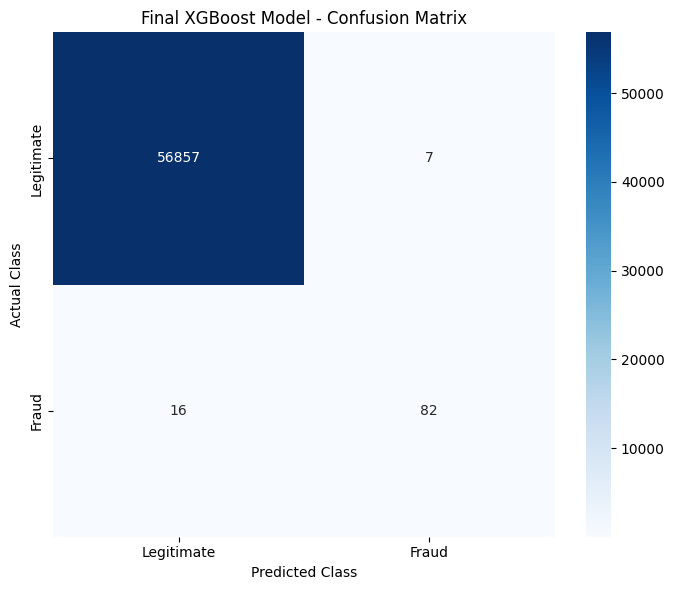

In [61]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Final XGBoost Model - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    "results/final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

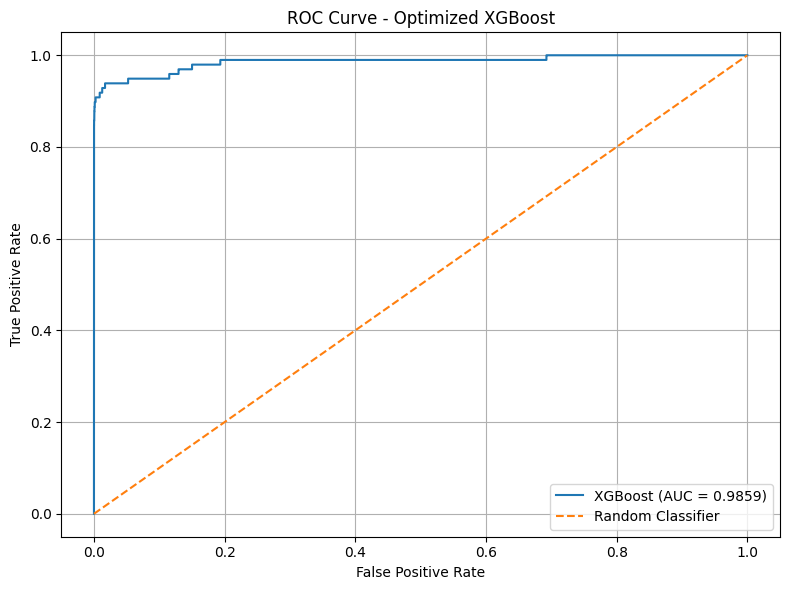

In [62]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(
    y_test,
    optimized_xgb_prob
)

roc_auc = roc_auc_score(
    y_test,
    optimized_xgb_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized XGBoost")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "results/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

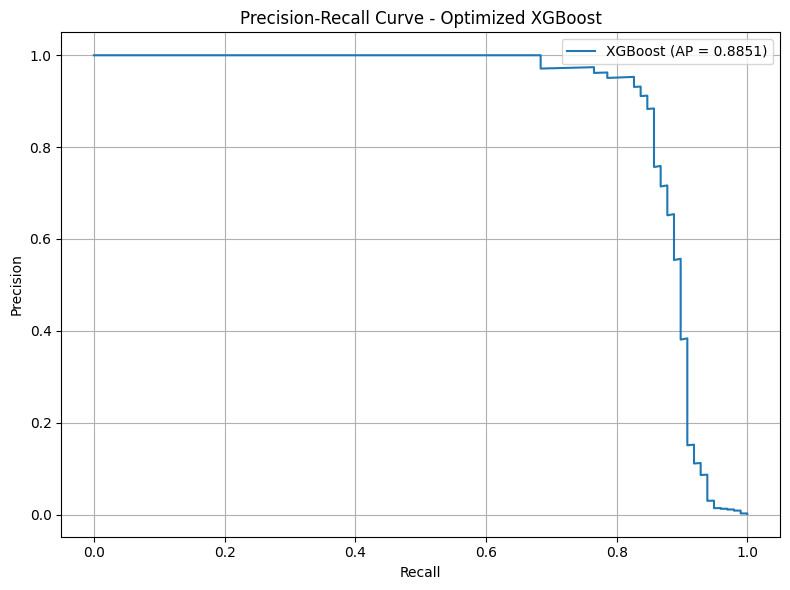

In [63]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(
    y_test,
    optimized_xgb_prob
)

pr_auc = average_precision_score(
    y_test,
    optimized_xgb_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"XGBoost (AP = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Optimized XGBoost")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "results/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
final_results_df = pd.DataFrame([final_results])

final_results_df.to_csv(
    "results/final_model_results.csv",
    index=False
)

print("Final model results saved.")

Final model results saved.


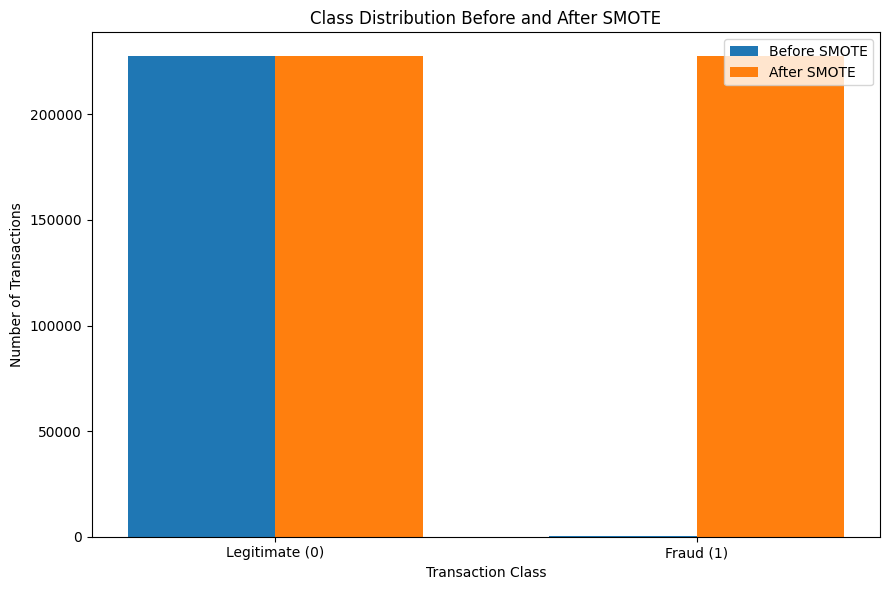

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Class counts from our SMOTE results
before_smote = {
    "Legitimate (0)": 227451,
    "Fraud (1)": 394
}

after_smote = {
    "Legitimate (0)": 227451,
    "Fraud (1)": 227451
}

classes = list(before_smote.keys())
x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width/2,
    list(before_smote.values()),
    width,
    label="Before SMOTE"
)

plt.bar(
    x + width/2,
    list(after_smote.values()),
    width,
    label="After SMOTE"
)

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution Before and After SMOTE")
plt.xticks(x, classes)
plt.legend()

plt.tight_layout()

# Save for Report 2
plt.savefig("class_distribution_smote.png", dpi=300, bbox_inches="tight")

plt.show()

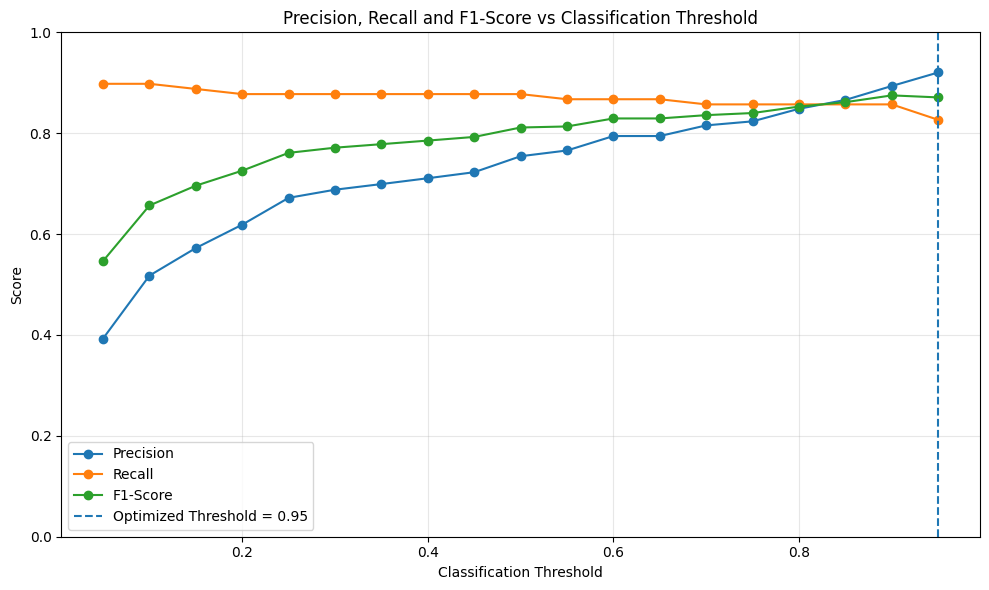

In [66]:
import matplotlib.pyplot as plt

thresholds = [
    0.05, 0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45, 0.50,
    0.55, 0.60, 0.65, 0.70, 0.75,
    0.80, 0.85, 0.90, 0.95
]

precision = [
    0.392857, 0.517647, 0.572368, 0.618705, 0.671875,
    0.688000, 0.699187, 0.710744, 0.722689, 0.754386,
    0.765766, 0.794393, 0.794393, 0.815534, 0.823529,
    0.848485, 0.865979, 0.893617, 0.920455
]

recall = [
    0.897959, 0.897959, 0.887755, 0.877551, 0.877551,
    0.877551, 0.877551, 0.877551, 0.877551, 0.877551,
    0.867347, 0.867347, 0.867347, 0.857143, 0.857143,
    0.857143, 0.857143, 0.857143, 0.826531
]

f1 = [
    0.546584, 0.656716, 0.696000, 0.725738, 0.761062,
    0.771300, 0.778281, 0.785388, 0.792627, 0.811321,
    0.813397, 0.829268, 0.829268, 0.835821, 0.840000,
    0.852792, 0.861538, 0.875000, 0.870968
]

plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision, marker='o', label='Precision')
plt.plot(thresholds, recall, marker='o', label='Recall')
plt.plot(thresholds, f1, marker='o', label='F1-Score')

plt.axvline(
    x=0.95,
    linestyle='--',
    label='Optimized Threshold = 0.95'
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-Score vs Classification Threshold")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

# Save for Report 2
plt.savefig(
    "threshold_optimization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

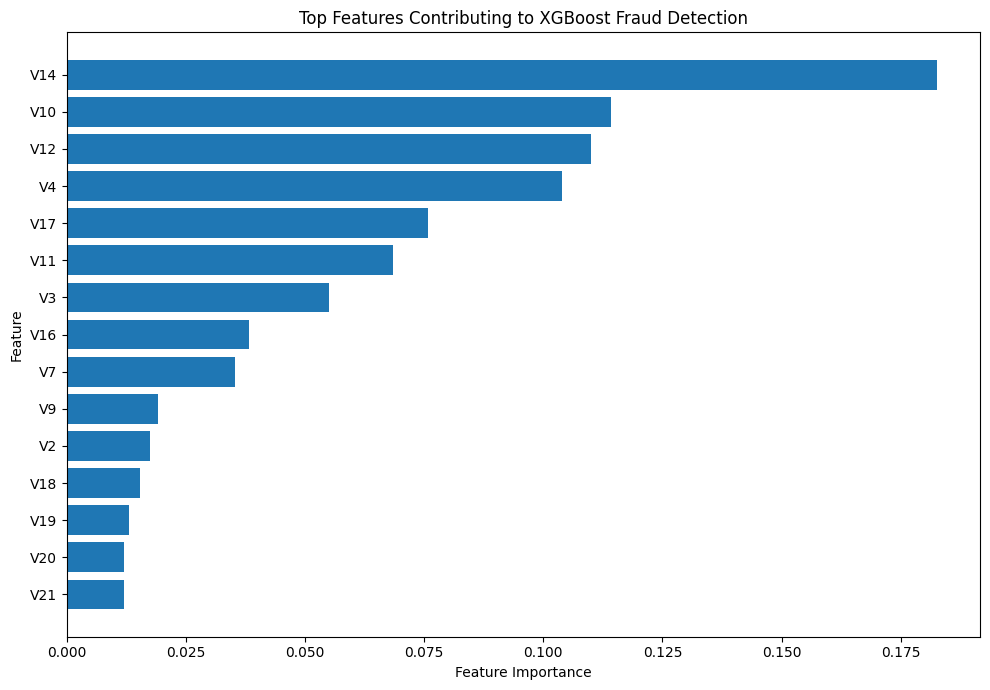

In [67]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series({
    "V14": 0.182485,
    "V10": 0.114241,
    "V12": 0.110069,
    "V4": 0.103889,
    "V17": 0.075887,
    "V11": 0.068388,
    "V3": 0.055113,
    "V16": 0.038244,
    "V7": 0.035377,
    "V9": 0.019262,
    "V2": 0.017464,
    "V18": 0.015406,
    "V19": 0.013057,
    "V20": 0.012107,
    "V21": 0.011990
})

# Sort for horizontal bar chart
feature_importance = feature_importance.sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance.index,
    feature_importance.values
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features Contributing to XGBoost Fraud Detection")

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()